## 0. Kaggle bootstrap

Run this cell **first** on Kaggle. It clones the fork (for `src/`), installs
`pytorch-msssim` / `torchinfo`, links your uploaded `dirty.npy` / `clean.npy`
Dataset as `./data`, and `chdir`s into `notebooks/` so the rest of the
notebook's `../data` and `../results` paths resolve. On a local machine it is a no-op.

**Kaggle setup:** Settings → Accelerator = *GPU*, Internet = *On*; then
*Add Input* → your uploaded data Dataset.


In [ ]:
# >>> KAGGLE BOOTSTRAP >>>  (no-op when not running on Kaggle)
import os, sys, subprocess, glob

if os.path.exists('/kaggle'):
    REPO_URL = 'https://github.com/KrishanYadav333/EXXA.git'
    BRANCH   = 'week-4'
    REPO     = '/kaggle/working/EXXA'
    PKG      = os.path.join(REPO, 'DENOISING_DIFFUSION')  # contains src/, notebooks/

    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '--branch', BRANCH, '--depth', '1', REPO_URL, REPO], check=True)

    # deps not guaranteed on the Kaggle image
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-msssim', 'torchinfo'], check=True)

    # expose the uploaded Kaggle Dataset as <repo>/data so '../data/*.npy' resolves
    os.makedirs(os.path.join(PKG, 'data'), exist_ok=True)
    hits = glob.glob('/kaggle/input/**/dirty.npy', recursive=True)
    if hits:
        src_dir = os.path.dirname(hits[0])
        for fn in ('dirty.npy', 'clean.npy'):
            dst = os.path.join(PKG, 'data', fn)
            if not os.path.exists(dst):
                try:
                    os.symlink(os.path.join(src_dir, fn), dst)
                except OSError:
                    import shutil; shutil.copy(os.path.join(src_dir, fn), dst)
    else:
        print('WARNING: dirty.npy not found under /kaggle/input — use *Add Input* to attach your data Dataset.')

    # run from notebooks/ so the existing '..'-relative paths work
    os.chdir(os.path.join(PKG, 'notebooks'))
    if PKG not in sys.path:
        sys.path.insert(0, PKG)

print('cwd :', os.getcwd())
# <<< KAGGLE BOOTSTRAP <<<

In [8]:
import sys
print(f"Python : {sys.version}")
print(f"Kernel : {sys.executable}")

Python : 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Kernel : k:\Krishan\GSoc\EXXA\.venv\Scripts\python.exe


# Data Exploration & Baselines

Quick look at the EXXA dataset + running classical denoising baselines to set a benchmark.

## 1. Environment check

In [9]:
import torch
import sys

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    device = torch.device('cpu')
    print('No GPU found, using CPU')

Python  : 3.13.5
PyTorch : 2.12.0+cpu
No GPU found, using CPU


## 2. Load and inspect the data

In [10]:
import numpy as np
import os

ROOT_DIR = os.path.normpath(os.path.join(os.path.abspath(''), '..'))
DATA_DIR = os.path.join(ROOT_DIR, 'data')

clean = np.load(os.path.join(DATA_DIR, 'clean.npy'))
dirty = np.load(os.path.join(DATA_DIR, 'dirty.npy'))

for name, arr in [('clean', clean), ('dirty', dirty)]:
    print(f'{name}: shape={arr.shape}, dtype={arr.dtype}, '
          f'range=[{arr.min():.4f}, {arr.max():.4f}], '
          f'mem={arr.nbytes / 1024**2:.0f} MB')

clean: shape=(975, 600, 600), dtype=float32, range=[0.0000, 1.0000], mem=1339 MB
dirty: shape=(975, 600, 600), dtype=float64, range=[0.0000, 1.0000], mem=2678 MB


In [11]:
# dtype mismatch -- dirty is float64 but clean is float32
# cast dirty to float32 so pytorch doesn't complain
if clean.dtype != dirty.dtype:
    print(f'dtype mismatch: clean={clean.dtype}, dirty={dirty.dtype}')
    dirty_f32 = dirty.astype(np.float32)
    print(f'cast dirty -> {dirty_f32.dtype}')
else:
    dirty_f32 = dirty

# quick sanity checks
assert clean.shape == dirty.shape, 'shape mismatch!'
assert 0.0 <= clean.min() and clean.max() <= 1.0
assert 0.0 <= dirty.min() and dirty.max() <= 1.0
print(f'{clean.shape[0]} paired samples, {clean.shape[1]}x{clean.shape[2]} px, range [0, 1]')

dtype mismatch: clean=float32, dirty=float64
cast dirty -> float32
975 paired samples, 600x600 px, range [0, 1]


**Notes:**
- 975 image pairs, 600x600 each
- Both normalized to [0, 1] already
- dirty is float64 (2.8 GB), clean is float32 (1.4 GB) -- need to cast dirty before training

## 3. Classical baselines

Running Gaussian, Median, and Wiener filters on 50 samples to get PSNR/SSIM/MSE numbers.

In [12]:
import sys
import matplotlib.pyplot as plt

if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.baselines import (
    gaussian_denoise, median_denoise, wiener_denoise,
    compute_metrics, run_baselines
)

print('running baselines on 50 samples...')
results = run_baselines(clean, dirty_f32, n_samples=50)
print('done')

running baselines on 50 samples...
  Processed 10/50
  Processed 20/50
  Processed 30/50
  Processed 40/50
  Processed 50/50

--- Baseline Results (averaged over 50 samples) ---
Method                PSNR       SSIM          MSE
--------------------------------------------------
Noisy              21.6579     0.2358     0.009048
Gaussian_s1        22.8625     0.4771     0.006917
Gaussian_s2        22.9181     0.5214     0.006806
Median_s3          22.9336     0.4358     0.006921
Wiener              22.693     0.4151     0.007186
done


In [13]:
# average metrics
methods = list(results.keys())
avg = {m: {k: float(np.mean(v)) for k, v in results[m].items()} for m in methods}

print(f'{"Method":<15} {"PSNR":>10} {"SSIM":>10} {"MSE":>12}')
print('-' * 50)
for m in methods:
    print(f'{m:<15} {avg[m]["PSNR"]:>10.4f} {avg[m]["SSIM"]:>10.4f} {avg[m]["MSE"]:>12.6f}')

Method                PSNR       SSIM          MSE
--------------------------------------------------
Noisy              21.6579     0.2358     0.009048
Gaussian_s1        22.8625     0.4771     0.006917
Gaussian_s2        22.9181     0.5214     0.006806
Median_s3          22.9336     0.4358     0.006921
Wiener             22.6930     0.4151     0.007186


## 4. Bar chart comparison

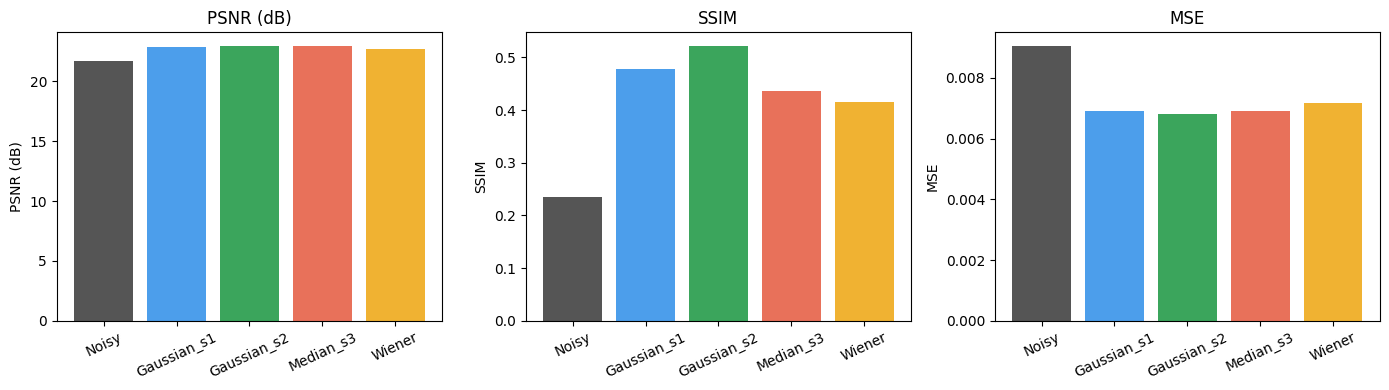

In [14]:
psnr_vals = [avg[m]['PSNR'] for m in methods]
ssim_vals = [avg[m]['SSIM'] for m in methods]
mse_vals  = [avg[m]['MSE']  for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, label in zip(axes, [psnr_vals, ssim_vals, mse_vals], ['PSNR (dB)', 'SSIM', 'MSE']):
    ax.bar(methods, vals, color=['#555','#4C9EEB','#3BA55C','#E8715A','#F0B232'][:len(methods)])
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../experiments/baseline_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample image comparison

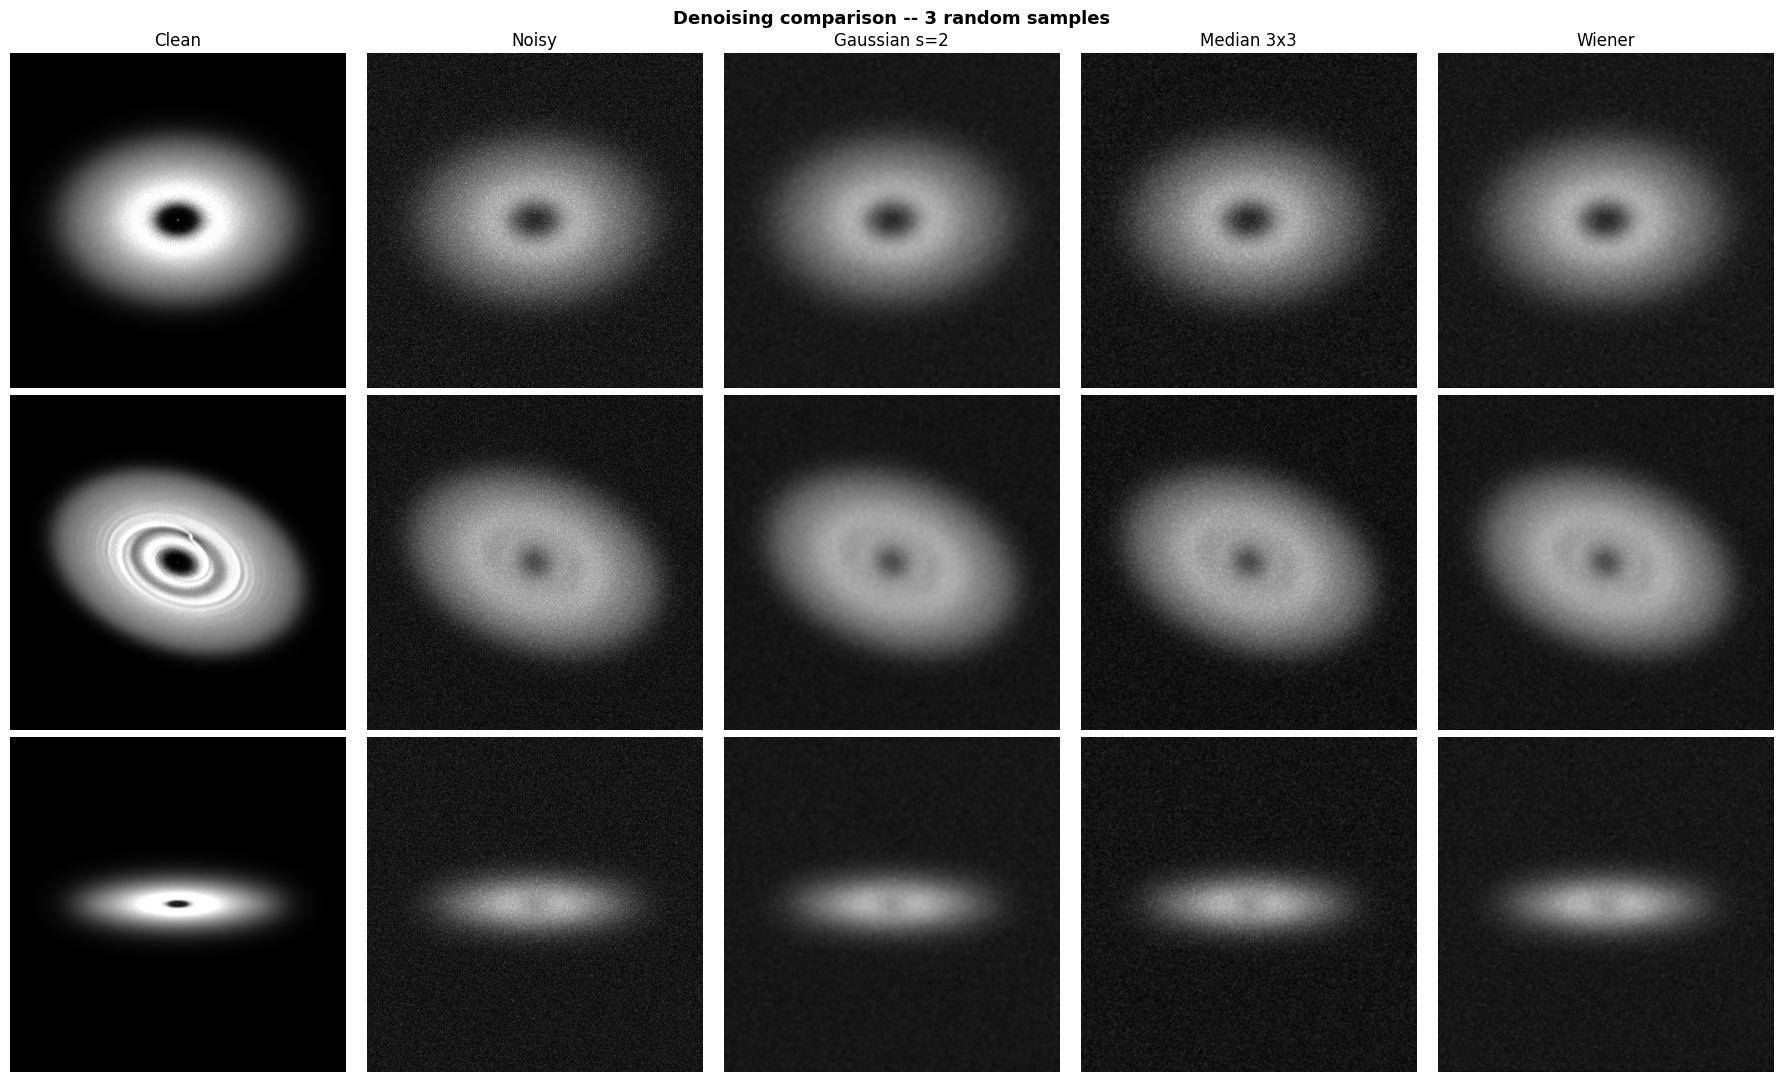

In [15]:
from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import wiener

np.random.seed(7)
sample_ids = np.random.choice(len(clean), 3, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
titles = ['Clean', 'Noisy', 'Gaussian s=2', 'Median 3x3', 'Wiener']

for row, idx in enumerate(sample_ids):
    c = clean[idx]
    d = dirty_f32[idx]
    imgs = [c, d,
            gaussian_filter(d, sigma=2),
            median_filter(d, size=3),
            wiener(d, (5,5))]

    for col, (img, title) in enumerate(zip(imgs, titles)):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'#{idx}', fontsize=10)

fig.suptitle('Denoising comparison -- 3 random samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/baseline_image_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Results summary

Averaged over 50 samples (600x600):

| Method | PSNR | SSIM | MSE |
|--------|------|------|-----|
| Noisy (input) | 21.66 | 0.236 | 0.009048 |
| Gaussian s=1 | 22.86 | 0.477 | 0.006917 |
| Gaussian s=2 | 22.92 | 0.521 | 0.006806 |
| Median 3x3 | 22.93 | 0.436 | 0.006921 |
| Wiener | 22.69 | 0.415 | 0.007186 |

Gaussian s=2 is the best classical method overall (highest SSIM, lowest MSE).
Target for ML models: beat PSNR > 22.93 and SSIM > 0.52.